# Siamese network

<img src='illustration/siamese.JPG'>

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import keras
from keras.layers import Input, Lambda, Dense, Flatten, MaxPool2D, Conv2D, GlobalAvgPool2D

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' # disable GPU
IMG_SHAPE = (28, 28, 1)
np.random.seed(1)

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1)/255
X_test = X_test.reshape(-1, 28, 28, 1)/255

In [4]:
def get_pair(X: np.array, y: np.array, coef=0.5) -> tuple:
    """
    This function creates pairs of images. Some belonging to the same class
    depending the ratio.
    
    Args:
        X (np.array): Image used to create the pairs
        y (np.array): class of each sample
        coef (float, optional): ratio of non pairs. Defaults to 0.5.

    Returns:
        tuple: X_pair with the pairs and y with 0 and 1 for each sample.
        1 => images are similars (i.e. they are true pairs, belongs to same class)
        0 => images are not similars
    """
    X_pair = np.empty(X.shape)
    y_pair = np.ones(y.shape, dtype=np.uint8)

    for i in range(10):
        n_samples = y[y == i].shape[0]

        idx = np.random.choice(np.where(y == i)[0], n_samples)
        X_pair[y == i] = X[idx]

        size = int(n_samples*coef)

        idx = np.random.choice(np.where(y == i)[0], size, replace=False)

        idx_false = np.random.choice(np.where(y != i)[0], size, replace=False)
        X_pair[idx] = X[idx_false]

        y_pair[idx] = 0

    return X_pair, y_pair

def show_sample(X: np.array, X_pair: np.array, y_pair: np.array, n_samples=10) -> None:
    """
    Show some pair samples

    Args:
        X (np.array): image
        X_pair (np.array): pair images
        y_pair (np.array): class of the pair are they similar or not
        n_samples (int, optional): number of sample to display. Defaults to 10.
    """
    for i in np.random.randint(0, X.shape[0], n_samples):
        plt.subplot(1, 2, 1)
        plt.imshow(X[i], cmap='gray')

        plt.subplot(1, 2, 2)
        plt.imshow(X_pair[i], cmap='gray')

        plt.suptitle(y_pair[i])

        plt.show()


In [5]:
X_train_pair, y_train_pair = get_pair(X_train, y_train)
X_test_pair, y_test_pair = get_pair(X_test, y_test)

In [6]:
print(X_train.shape)
X_train_pair.shape

(60000, 28, 28, 1)


(60000, 28, 28, 1)

In [7]:
# show_sample(X_train, X_train_pair, y_train_pair)

In [8]:
def get_cnn(initializer='glorot_uniform') -> keras.Model:
    """   
    Build Simple CNN architecture for siamese Network.
    We Tried a lot of different architectures with Optuna for HP optimization but it seems really
    hard to find other viable architectures.

    2 Convolution layers and one Dense

    Args:
        initializer (str): kernel initializer Used for layers. Defaults to glorot_uniform

    Returns:
        keras.Model: CNN model
    """
    inputs = Input(IMG_SHAPE)

    x = Conv2D(64, 4, activation='relu', kernel_initializer=initializer)(inputs)
    x = MaxPool2D()(x)

    x = Conv2D(64, 4, activation='relu', kernel_initializer=initializer)(x)
    x = MaxPool2D()(x)

    x = Flatten()(x)
    # x = GlobalAvgPool2D()(x) 
    outputs = Dense(128, activation='relu', kernel_initializer=initializer)(x)

    cnn = keras.Model(inputs, outputs)
    return cnn

def euclidean_distance(tensors: list):
    """
    Compare two tensors. The more the distance is high the more the tensor are non similar.
    Tensors are extracted by the CNN

    Args:
        tensors (list): List with the two tensors

    Returns:
        Float: euclidean distance
    """
    left, right = tensors
    # distance = left-right
    # distance = keras.ops.square(distance)
    # distance = keras.ops.sum(distance, keepdims=True, axis=1)
    # distance = keras.ops.sqrt(keras.ops.maximum(distance, 1e-18))
    distance = keras.ops.maximum(keras.ops.norm(left-right, keepdims=True, axis=1), 1e-10) # 1* 10^-18
    return distance

def get_siamese(initializer='glorot_uniform') -> keras.Model:
    """
    Get the CNN and extract the tensors from the two input images. 
    Then we compute the euclidean distance between the two vectors.

    Args:
        initializer (str, optional): [description]. Defaults to 'glorot_uniform'.

    Returns:
        keras.Model: Siamese network
    """
    cnn = get_cnn(initializer=initializer)

    img_left = Input(IMG_SHAPE)
    img_right = Input(IMG_SHAPE)

    left = cnn(img_left)
    right = cnn(img_right)

    distance = Lambda(euclidean_distance, name='euclidean_distance')((left, right))

    outputs = Dense(1, activation='sigmoid')(distance)

    siamese = keras.Model([img_left, img_right], outputs)

    return siamese

In [9]:
keras.utils.plot_model(get_siamese(),
                       expand_nested=True,
                       show_shapes=True)


('You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) ', 'for plot_model/model_to_dot to work.')


In [10]:
siamese = get_siamese() # glorot_uniform > he_normal

siamese.compile(loss='binary_crossentropy',
                metrics=['accuracy'],
                optimizer=keras.optimizers.Adam(learning_rate=0.01)) 

history = siamese.fit([X_train, X_train_pair], y_train_pair,
                      validation_data=([X_test, X_test_pair], y_test_pair),
                      epochs=2)


Epoch 1/2
1875/1875 [==============================] - 100s 53ms/step - loss: 0.2048 - accuracy: 0.9283 - val_loss: 0.0805 - val_accuracy: 0.9744
Epoch 2/2
1875/1875 [==============================] - 98s 52ms/step - loss: 0.0663 - accuracy: 0.9794 - val_loss: 0.0536 - val_accuracy: 0.9807


              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4999
           1       0.98      0.98      0.98      5001

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



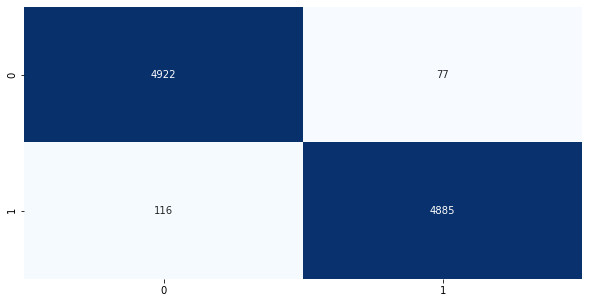

(193,)


In [13]:
y_pred = siamese.predict([X_test, X_test_pair])

y_pred = np.round(y_pred)
y_pred = y_pred.astype(int).reshape(-1)

print(classification_report(y_test_pair, y_pred))

plt.figure(figsize=(10, 5))
sns.heatmap(confusion_matrix(y_test_pair, y_pred),
            annot=True, cbar=False, fmt='d', cmap='Blues')
plt.show()

errors = np.where(y_test_pair != y_pred)[0]
print(errors.shape)

X = X_test[errors]
X_pair = X_test_pair[errors]
y_pair = y_test_pair[errors]


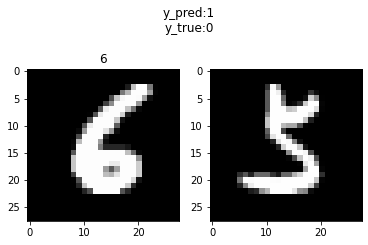

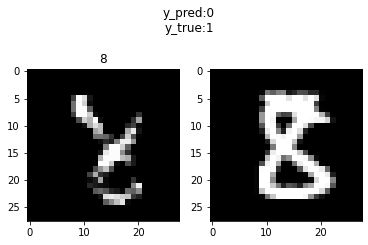

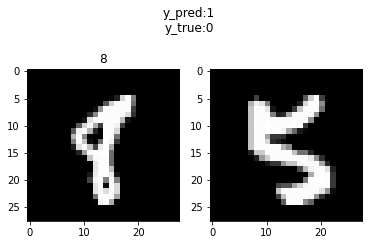

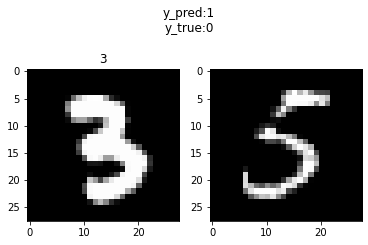

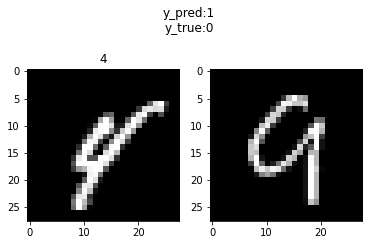

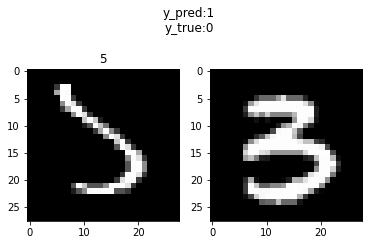

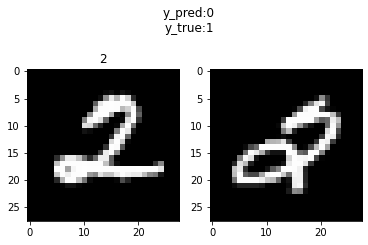

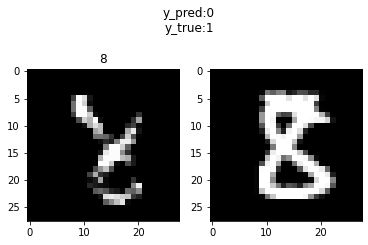

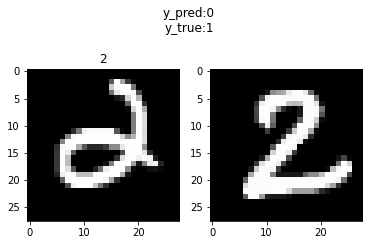

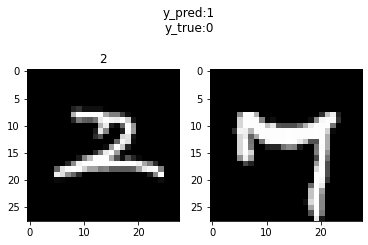

In [14]:
# TODO: Call a function
for i in np.random.randint(0, X.shape[0], 10):
    
    plt.subplot(1, 2, 1)
    plt.title(y_test[errors][i])
    plt.imshow(X[i], cmap='gray')

    plt.subplot(1, 2, 2)
    plt.imshow(X_pair[i], cmap='gray')

    plt.suptitle('y_pred:%s\ny_true:%s'%(y_pred[errors][i], y_pair[i]))

    plt.show()